In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('5.2-)insurance.csv')

In [3]:
df.head() # Charges odenen tutardır buna gore model tahmni yapacak

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df['sex'] =np.where(df['sex'].str.contains('female') , 0 , 1) # Kadın -> 0 , Erkek -> 1

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [7]:
df['smoker'] = np.where(df['smoker'].str.contains('yes') , 1 , 0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


In [9]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [10]:
df = pd.get_dummies(df , columns = ['region'])

In [11]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northeast  1338 non-null   bool   
 7   region_northwest  1338 non-null   bool   
 8   region_southeast  1338 non-null   bool   
 9   region_southwest  1338 non-null   bool   
dtypes: bool(4), float64(2), int64(4)
memory usage: 68.1 KB


In [13]:
#----------------------------------MACHINE LEARNING ----------------------------------

In [14]:
X = df.drop(columns = 'charges' , axis = 1)
y = df['charges']

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25, random_state = 20  )

In [17]:
# --------- CORRELATION FOR DROP COLUMNS ---------

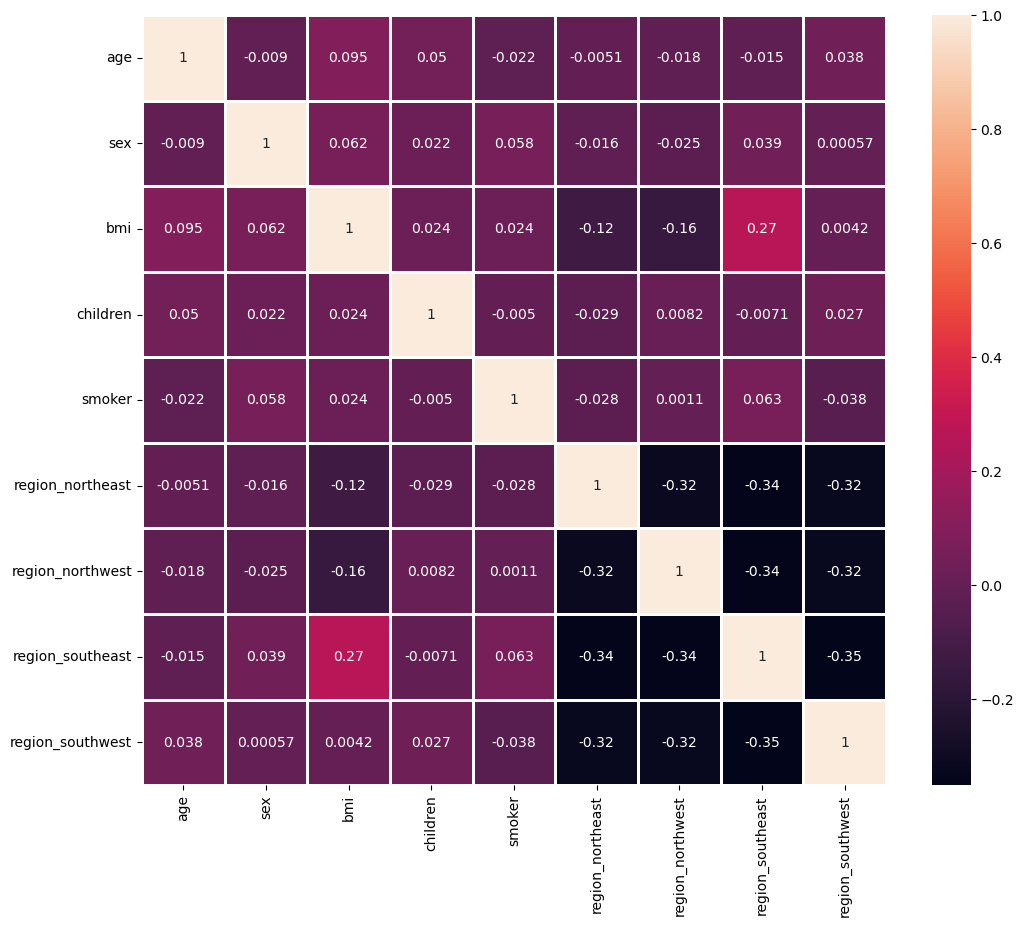

In [18]:
fig = plt.figure(figsize = (12,10))
sns.heatmap(X_train.corr() , annot = True , linewidth = 1)
plt.show()

In [19]:
X_train.corr()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
age,1.000000,-0.008980,0.094716,0.050207,-0.021659,-0.005081,-0.017855,-0.014516,0.037554
sex,-0.008980,1.000000,0.061894,0.022409,0.057997,-0.015774,-0.025108,0.038775,0.000574
bmi,0.094716,0.061894,1.000000,0.023513,0.023815,-0.124605,-0.155059,0.265009,0.004179
children,0.050207,0.022409,0.023513,1.000000,-0.005050,-0.028542,0.008227,-0.007130,0.027384
smoker,-0.021659,0.057997,0.023815,-0.005050,1.000000,-0.028178,0.001079,0.063238,-0.038151
region_northeast,-0.005081,-0.015774,-0.124605,-0.028542,-0.028178,1.000000,-0.316273,-0.342184,-0.324044
region_northwest,-0.017855,-0.025108,-0.155059,0.008227,0.001079,-0.316273,1.000000,-0.342184,-0.324044
region_southeast,-0.014516,0.038775,0.265009,-0.007130,0.063238,-0.342184,-0.342184,1.000000,-0.350592
region_southwest,0.037554,0.000574,0.004179,0.027384,-0.038151,-0.324044,-0.324044,-0.350592,1.000000


In [20]:
def corelation_for_dropping(df , treshold) : 
    corr = df.corr()
    columns_to_drop = set()
    for i in range(len(corr.columns)) : 
        for j in range(i) : 
            if abs(corr.iloc[i , j ]) > treshold : 
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop

In [21]:
dropped_columns = corelation_for_dropping(X_train , 0.85)
dropped_columns
# EMPTY 

set()

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

In [24]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
regression = LinearRegression()

In [27]:
regression.fit(X_train , y_train)

LinearRegression()

In [28]:
y_pred = regression.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [30]:
r2_score(y_test , y_pred)

0.7715412086749973

In [32]:
from lazypredict.Supervised import LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

print(models)

  0%|          | 0/42 [00:00<?, ?it/s]

  File "C:\Users\MSI-NB\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\MSI-NB\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MSI-NB\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MSI-NB\anaconda3\Lib\subproc

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001869 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 328
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 9
[LightGBM] [Info] Start training from score 13145.909916
                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
GradientBoostingRegressor                    0.88       0.89   4135.58   
RandomForestRegressor                        0.87       0.87   4347.02   
LGBMRegressor                                0.87       0.87   4354.13   
HistGradientBoostingRegressor                0.87       0.87   4381.97   
BaggingRegressor                             0.87       0.87   4386.56   
ExtraTreesRegressor                          0.84       0.85   4814.37   
A